In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)


In [2]:
dt = pd.read_csv(r'/content/marketing (1).csv')

In [3]:
dt

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
0,13829,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,-1,0,unknown,no
1,22677,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,-1,0,unknown,no
2,10541,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,-1,0,unknown,no
3,13689,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,-1,0,unknown,no
4,11304,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,14023,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,87,5,failure,yes
12866,17259,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,93,2,failure,yes
12867,15200,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,172,2,failure,no
12868,13775,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,-1,0,unknown,no


In [4]:
dt.describe(include='all')

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
count,12870.000000,12870.000000,12870,12870,12870,12870,12870.000000,12870,12870,12870,12870.000000,12870,12870.000000,12870.000000,12870.000000,12870,12870
unique,NaN,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,4,2
top,NaN,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,unknown,no
freq,NaN,NaN,2858,7490,6368,12662,NaN,6605,11060,8756,NaN,3594,NaN,NaN,NaN,10070,8903
mean,16434.500000,41.091142,NaN,NaN,NaN,NaN,1483.774437,NaN,NaN,NaN,15.641103,NaN,2.659130,45.555478,0.688967,NaN,NaN
std,3715.393317,11.305560,NaN,NaN,NaN,NaN,3311.055181,NaN,NaN,NaN,8.368983,NaN,2.863507,104.449411,2.049696,NaN,NaN
min,10000.000000,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
25%,13217.250000,32.000000,NaN,NaN,NaN,NaN,102.000000,NaN,NaN,NaN,8.000000,NaN,1.000000,-1.000000,0.000000,NaN,NaN
50%,16434.500000,39.000000,NaN,NaN,NaN,NaN,515.000000,NaN,NaN,NaN,16.000000,NaN,2.000000,-1.000000,0.000000,NaN,NaN
75%,19651.750000,49.000000,NaN,NaN,NaN,NaN,1591.750000,NaN,NaN,NaN,21.000000,NaN,3.000000,-1.000000,0.000000,NaN,NaN


In [5]:
dt.columns

Index(['ID', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays',
       'previous', 'response', 'result'],
      dtype='object')

In [6]:
dt.drop(dt[['ID','pdays', 'previous']],axis=1, inplace=True)

In [7]:
dt['result'] = np.where(dt['result']=='yes',0,1)

In [8]:
dt.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [9]:
dt['age_group'] = pd.cut(dt['age'],
                          bins=[0, 25, 35, 50, 65, 100],
                          labels=['young', 'young_adult', 'middle_aged', 'senior', 'elderly'])

In [10]:
dt['financial_pressure'] = (
    (dt['housing'] == 'yes').astype(int) +
    (dt['loan'] == 'yes').astype(int)
)

In [11]:
dt['wealthy_no_debt'] = (
    (dt['balance'] > dt['balance'].mean()).astype(int) *
    (dt['housing'] == 'no').astype(int) *
    (dt['loan'] == 'no').astype(int)
)

In [12]:
dt['default_flag'] = (dt['default'] == 'yes').astype(int)
dt['risk_profile'] = dt['default_flag'] + dt['financial_pressure']

In [13]:
dt['previous_campaign_success'] = (dt['response'] == 'success').astype(int)

In [14]:
dt['balance_per_age'] = dt['balance'] / dt['age']

In [15]:
dt['high_balance_flag'] = (dt['balance'] > dt['balance'].mean()).astype(int)

In [16]:
dt_rf = dt.copy()
dt_knn = dt.copy()

## Model-Specific Preprocessing: Random Forest

In [17]:
le = LabelEncoder()
dt_rf['job'] = le.fit_transform(dt_rf['job'])
dt_rf['marital'] = le.fit_transform(dt_rf['marital'])
dt_rf['month'] = le.fit_transform(dt_rf['month'])
dt_rf['contact'] = le.fit_transform(dt_rf['contact'])

In [18]:
dt_rf['education'] = dt_rf['education'].map({'unknown':0,'primary':1,'secondary':2,'tertiary':3})
dt_rf['default'] = dt_rf['default'].map({'yes':0,'no':1})
dt_rf['housing'] = dt_rf['housing'].map({'yes':0,'no':1})
dt_rf['loan'] = dt_rf['loan'].map({'yes':0,'no':1})
dt_rf['response'] = dt_rf['response'].map({'unknown':0,'failure':1,'success':2,'other':3})
dt_rf['age_group'] = dt_rf['age_group'].map({'young':0,'young_adult':1,'middle_aged':2,'senior':3,'elderly':4})

## Model-Specific Preprocessing: KNN

### Outlier Treatment

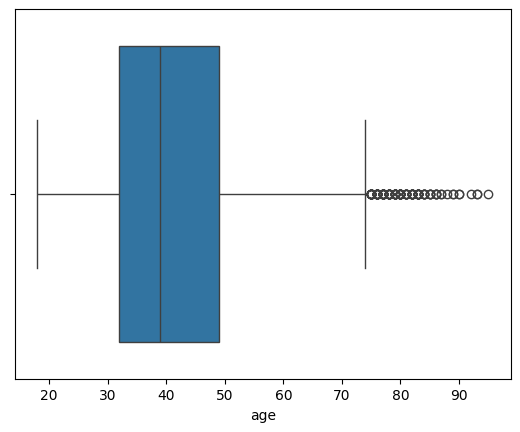

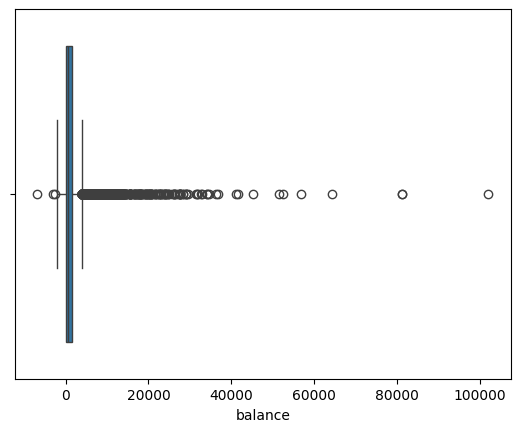

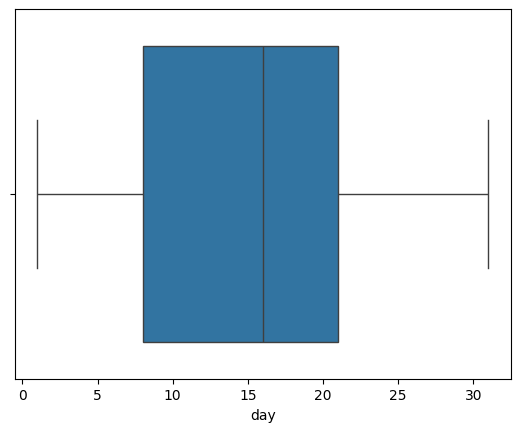

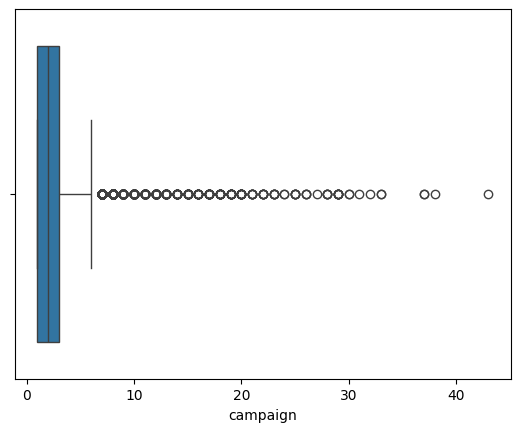

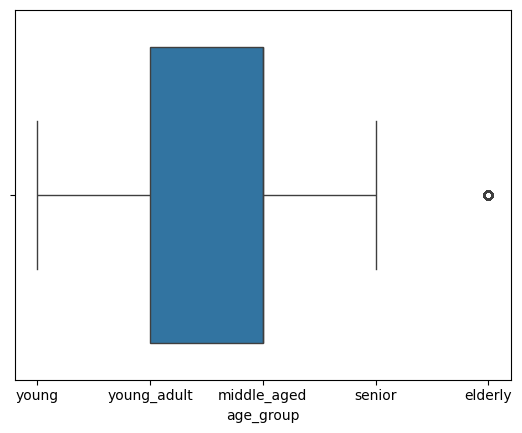

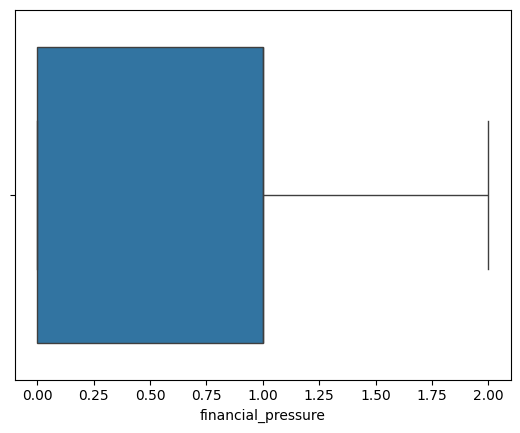

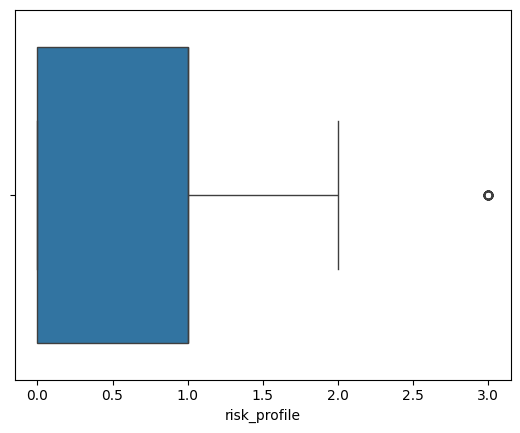

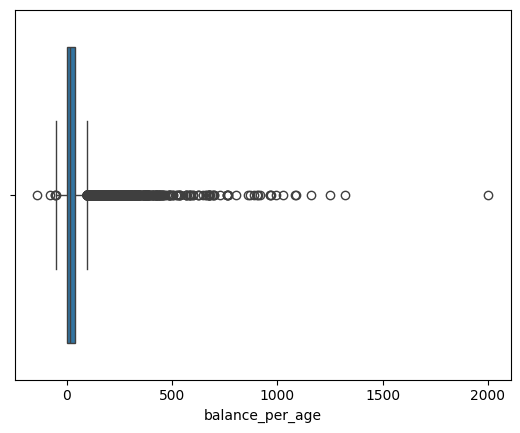

In [19]:
for i in dt_knn.columns:
  if dt_knn[i].dtypes != object and i not in ['result','wealthy_no_debt','default_flag','previous_campaign_success','high_balance_flag']:
    sns.boxplot(data=dt_knn, x=dt_knn[i])
    plt.show()

In [20]:
q1 = dt_knn.quantile(0.25, numeric_only=True)
q3 = dt_knn.quantile(0.75, numeric_only=True)
iqr = q3-q1

upper = q3+ 1.5*iqr
lower = q1- 1.5*iqr

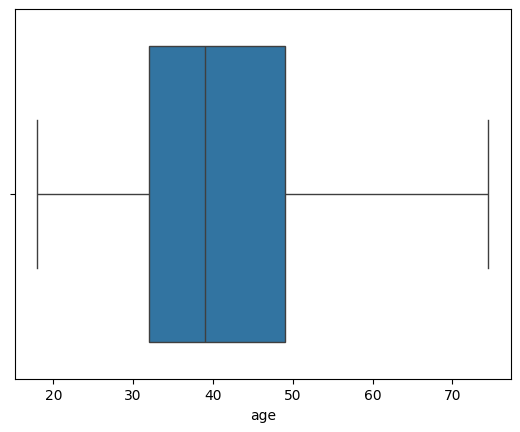

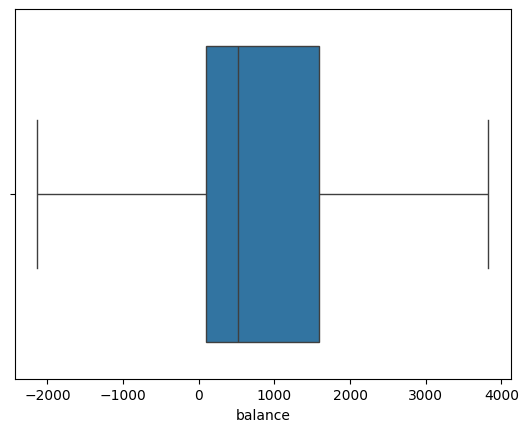

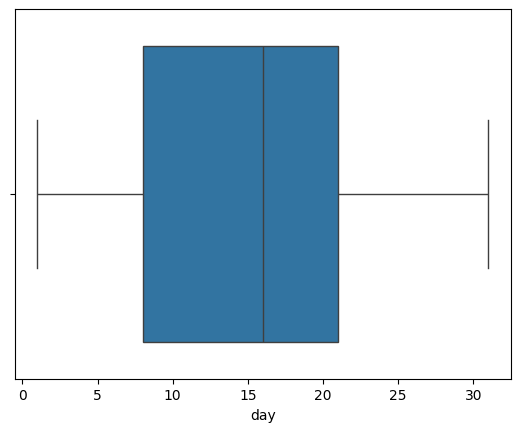

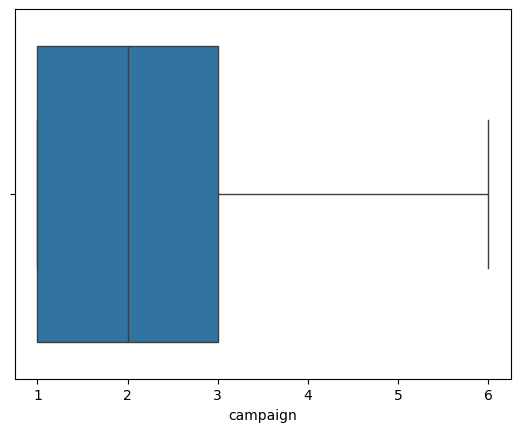

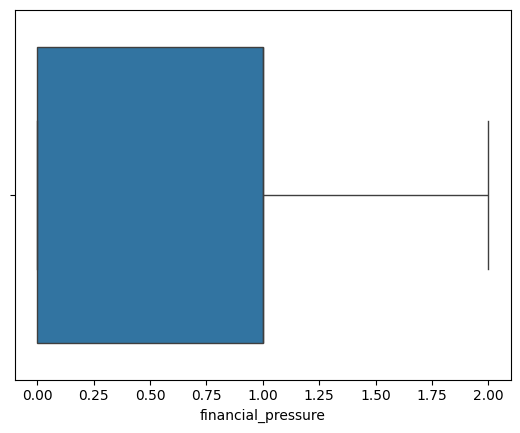

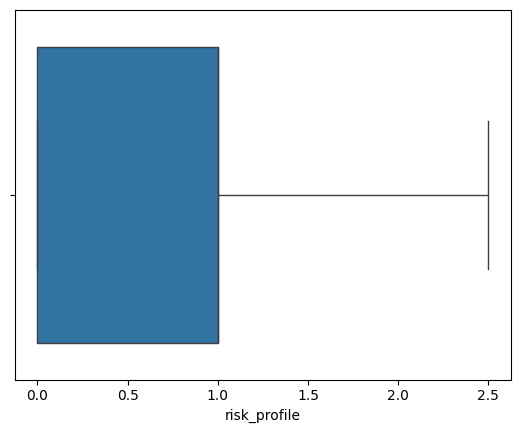

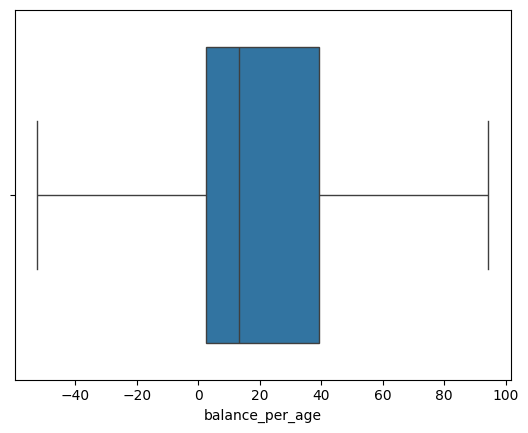

In [21]:
for i in dt_knn.columns:
  if dt_knn[i].dtypes in ['int64','float64'] and i not in ['result','wealthy_no_debt','default_flag','previous_campaign_success','high_balance_flag']:
    dt_knn[i] = np.where(dt_knn[i]> upper[i], upper[i], dt_knn[i])
    dt_knn[i] = np.where(dt_knn[i]< lower[i], lower[i], dt_knn[i])
    sns.boxplot(data=dt_knn, x=dt_knn[i])
    plt.show()


### Normality Test

In [22]:
from scipy import stats

for i in dt_knn.columns:
  if dt_knn[i].dtypes in ['int64', 'float64']:

    kstest_statistic, kstest_p_value = stats.kstest(dt_knn[i], 'norm')

    print(f'Column: {i}')
    print(f'p-value: {kstest_p_value}')

    if kstest_p_value > 0.05:
      print('Data looks normally distributed')
      print()
    else:
      print('Data does not look normally distributed')
      print()

Column: age
p-value: 0.0
Data does not look normally distributed

Column: balance
p-value: 0.0
Data does not look normally distributed

Column: day
p-value: 0.0
Data does not look normally distributed

Column: campaign
p-value: 0.0
Data does not look normally distributed

Column: result
p-value: 0.0
Data does not look normally distributed

Column: financial_pressure
p-value: 0.0
Data does not look normally distributed

Column: wealthy_no_debt
p-value: 0.0
Data does not look normally distributed

Column: default_flag
p-value: 0.0
Data does not look normally distributed

Column: risk_profile
p-value: 0.0
Data does not look normally distributed

Column: previous_campaign_success
p-value: 0.0
Data does not look normally distributed

Column: balance_per_age
p-value: 0.0
Data does not look normally distributed

Column: high_balance_flag
p-value: 0.0
Data does not look normally distributed



### Feature Selection

In [23]:
def targetcorr (data,target,threshold=0.1):
  corr = data.corr(method='spearman',numeric_only=True)
  target_corr = corr[target].abs() > threshold
  variables_explaining_target = target_corr[target_corr].index.tolist()

  variables_explaining_target.remove(target)

  result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr.loc[variables_explaining_target, target]})

  result_explaining_target.reset_index(drop=True, inplace=True)

  return result_explaining_target

target_result = targetcorr(dt_knn, 'result')
target_result

,Variable,Correlation with Target
0,balance,-0.139456
1,campaign,0.121709
2,financial_pressure,0.215935
3,wealthy_no_debt,-0.165518
4,risk_profile,0.218351
5,previous_campaign_success,-0.311520
6,balance_per_age,-0.139648
7,high_balance_flag,-0.111299


In [24]:
target_result.Variable.tolist()

['balance',
 'campaign',
 'financial_pressure',
 'wealthy_no_debt',
 'risk_profile',
 'previous_campaign_success',
 'balance_per_age',
 'high_balance_flag']

In [25]:
def intercorr(data,target, threshold=0.7):
  corr = data.corr(method='spearman',numeric_only=True)
  mask = np.triu(np.ones(corr.shape), k= 1).astype(bool)
  high_corr = corr.where(mask).stack().reset_index()
  high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]

  high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]

  return high_corr.reset_index(drop=True)

intercorrelated_result = intercorr(dt_knn, 'result')

intercorrelated_result

,Variable 1,Variable 2,Correlation
0,balance,balance_per_age,0.987895
1,balance,high_balance_flag,0.765315
2,financial_pressure,risk_profile,0.988032
3,balance_per_age,high_balance_flag,0.752016


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(data,variables):
  vif_data = data[variables]
  vif_value = [variance_inflation_factor(vif_data.values,i) for i in range (vif_data.shape[1])]
  vif_result = pd.DataFrame({'Feature': variables,'VIF': vif_value})
  return vif_result


In [27]:
vif_result_ = calc_vif(dt_knn,[#'balance',
 'campaign',
 #'financial_pressure',
 'wealthy_no_debt',
 'risk_profile',
 'previous_campaign_success',
 'balance_per_age',
 #'high_balance_flag'
                               ])
vif_result_

,Feature,VIF
0,campaign,1.881614
1,wealthy_no_debt,2.003848
2,risk_profile,1.826284
3,previous_campaign_success,1.054935
4,balance_per_age,2.365438


### Encoding & Scaling

In [28]:
dt_knn.drop(dt_knn[['age','balance','day','age_group','financial_pressure','default_flag','high_balance_flag']],axis=1,inplace=True)

In [29]:
dt_knn['education'] = dt_knn['education'].map({'unknown':0,'primary':1,'secondary':2,'tertiary':3})
dt_knn['default'] = dt_knn['default'].map({'yes':0,'no':1})
dt_knn['housing'] = dt_knn['housing'].map({'yes':0,'no':1})
dt_knn['loan'] = dt_knn['loan'].map({'yes':0,'no':1})
dt_knn['response'] = dt_knn['response'].map({'unknown':0,'failure':1,'success':2,'other':3})

In [30]:
dt_knn= pd.get_dummies(dt_knn, drop_first=True, dtype=int)

In [31]:
target = dt['result']
inputs_rf = dt_rf.drop(dt_rf[['result']],axis=1)
inputs_knn = dt_knn.drop(dt_knn[['result']],axis=1)

In [129]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(inputs_knn)

inputs_scaled = scaler.transform(inputs_knn)
data_scaled = pd.DataFrame(inputs_scaled, columns=inputs_knn.columns)
joblib.dump(scaler, 'scaler.pkl')

data_scaled



,education,default,housing,loan,campaign,response,wealthy_no_debt,risk_profile,previous_campaign_success,balance_per_age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,1.156337,0.128168,1.026776,0.404540,-0.212008,-0.468231,2.479919,-1.045495,-0.265085,2.176373,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,2.238573,-0.182310,-0.079088,-1.179912,1.515181,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,1.606539,-0.304796,-0.164228,-0.147489
1,-0.108176,0.128168,-0.973922,-2.471942,0.423719,-0.468231,-0.403239,2.081514,-0.265085,-0.195959,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,3.367403,-0.169152,-0.446713,-0.182310,-0.079088,-1.179912,1.515181,-0.270087,1.724369,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,2.769929,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
2,-0.108176,0.128168,1.026776,0.404540,-0.212008,-0.468231,-0.403239,-1.045495,-0.265085,-0.678777,-0.499636,-0.175134,-0.163228,1.871670,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,-1.179912,1.515181,-0.270087,-0.579922,2.471148,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
3,-2.637203,0.128168,-0.973922,0.404540,-0.847735,-0.468231,-0.403239,0.518010,-0.265085,-0.798534,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,2.238573,-0.182310,-0.079088,0.847521,-0.659987,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,2.461664,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
4,-0.108176,0.128168,1.026776,-2.471942,-0.847735,-0.468231,-0.403239,0.518010,-0.265085,-0.443955,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,-1.179912,1.515181,-0.270087,1.724369,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,6.780177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,-0.108176,0.128168,-0.973922,0.404540,-0.847735,0.788522,-0.403239,0.518010,-0.265085,-0.032688,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,2.238573,-0.182310,-0.079088,0.847521,-0.659987,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
12866,-0.108176,0.128168,1.026776,0.404540,-0.212008,0.788522,-0.403239,-1.045495,-0.265085,-0.707994,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,12.644169,0.847521,-0.659987,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,3.280879,-0.164228,-0.147489
12867,1.156337,0.128168,-0.973922,0.404540,-0.847735,0.788522,-0.403239,0.518010,-0.265085,0.308563,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,5.485158,-0.079088,-1.179912,1.515181,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,3.280879,-0.164228,-0.147489
12868,1.156337,0.128168,-0.973922,0.404540,-0.212008,-0.468231,-0.403239,0.518010,-0.265085,-0.459341,-0.499636,-0.175134,-0.163228,1.871670,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,0.847521,-0.659987,-0.270087,1.724369,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,1.606539,-0.304796,-0.164228,-0.147489


##  Train / Test Split

In [33]:
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(inputs_rf, target, test_size = 0.3, random_state = 42)
x_train_knn, x_test_knn, y_train_knn, y_test_knn = train_test_split(data_scaled, target, test_size = 0.3, random_state = 42)

###  Model Evaluation Function

In [34]:
def evaluate (model, x_train,y_train, x_test,y_test):
    y_train_pred = model.predict(x_train)
    y_train_prob = model.predict_proba(x_train)[:, 1]

    y_test_pred = model.predict(x_test)
    y_test_prob = model.predict_proba(x_test)[:, 1]

    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)

    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    confusion_matrix = metrics.confusion_matrix(y_test, y_test_pred)

    return results , confusion_matrix

### Baseline Models

In [35]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train_rf,y_train_rf)

RandomForestClassifier(random_state=42)

In [36]:
rf_scores = evaluate(rf,x_train_rf,y_train_rf,x_test_rf,y_test_rf)
rf_scores

(  Dataset        Gini  Precision    Recall
 0   Train  100.000000   1.000000  1.000000
 1    Test   51.223614   0.789962  0.916203,
 array([[ 507,  657],
        [ 226, 2471]]))

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_knn,y_train_knn)

KNeighborsClassifier()

In [38]:
knn_scores = evaluate(knn,x_train_knn,y_train_knn,x_test_knn,y_test_knn)
knn_scores

(  Dataset       Gini  Precision    Recall
 0   Train  74.549390   0.825076  0.920400
 1    Test  40.047584   0.782106  0.878383,
 array([[ 504,  660],
        [ 328, 2369]]))

## Hyperparameter Optimization

In [39]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.7 MB/s eta 0:00:00


In [40]:
from sklearn.model_selection import cross_val_score
import optuna

In [41]:
def best_params_for_model(trial):
    param = {
    'n_neighbors': trial.suggest_int('n_neighbors', 1, 50),
    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
    'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute']),
    'leaf_size': trial.suggest_int('leaf_size', 10, 50),
    'p': trial.suggest_int('p', 1, 2),
    'metric': trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan'])
}

    knn_clf = KNeighborsClassifier(**param)

    roc = cross_val_score(knn_clf, x_train_knn, y_train_knn, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=50)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_knn_model = KNeighborsClassifier(**best_params)

[I 2026-04-17 06:53:00,471] A new study created in memory with name: no-name-a308f6cd-3b67-487f-b5c1-522663c2e31e
[I 2026-04-17 06:53:08,232] Trial 0 finished with value: 0.7368191981400034 and parameters: {'n_neighbors': 47, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 24, 'p': 1, 'metric': 'euclidean'}. Best is trial 0 with value: 0.7368191981400034.
[I 2026-04-17 06:53:09,190] Trial 1 finished with value: 0.7309422777197031 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 14, 'p': 2, 'metric': 'minkowski'}. Best is trial 0 with value: 0.7368191981400034.
[I 2026-04-17 06:53:10,299] Trial 2 finished with value: 0.7424688420785526 and parameters: {'n_neighbors': 45, 'weights': 'uniform', 'algorithm': 'auto', 'leaf_size': 49, 'p': 2, 'metric': 'euclidean'}. Best is trial 2 with value: 0.7424688420785526.
[I 2026-04-17 06:53:22,503] Trial 3 finished with value: 0.7395515670649486 and parameters: {'n_neighbors': 49, 'weights': 'dis

Best trial:
  Value: 0.751
  Params:  {'n_neighbors': 50, 'weights': 'uniform', 'algorithm': 'brute', 'leaf_size': 50, 'p': 1, 'metric': 'minkowski'}


In [42]:
best_knn_model = best_knn_model.fit(x_train_knn, y_train_knn)
best_knn_score = evaluate(best_knn_model,x_train_knn, y_train_knn,x_test_knn,y_test_knn )
best_knn_score

(  Dataset       Gini  Precision    Recall
 0   Train  56.524845   0.779809  0.934741
 1    Test  50.005415   0.780729  0.937338,
 array([[ 454,  710],
        [ 169, 2528]]))

In [43]:
def best_params_for_model(trial):
    param = {
    'n_estimators': trial.suggest_int('n_estimators', 100, 400),
    'max_features': trial.suggest_float('max_features', 0.3, 0.5),
    'max_depth': trial.suggest_int('max_depth', 10,100),
    'min_samples_split': trial.suggest_int('min_samples_split', 20,40),
    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5,8),
    }

    rf_opt = RandomForestClassifier(**param)

    roc = cross_val_score(rf_opt, x_train_rf,y_train_rf, cv=5, scoring='roc_auc', n_jobs=-1).mean()
    return roc

study = optuna.create_study(direction='maximize')
study.optimize(best_params_for_model, n_trials=30)

print('Best trial:')
best_params = study.best_params
print('  Value: {:.3f}'.format(study.best_value))
print('  Params: ', best_params)

best_rf_model = RandomForestClassifier(**best_params)

[I 2026-04-17 06:56:10,708] A new study created in memory with name: no-name-492bde00-a6d5-4e95-922d-ae0bff13daa1
[I 2026-04-17 06:56:29,818] Trial 0 finished with value: 0.7774977141917528 and parameters: {'n_estimators': 209, 'max_features': 0.42639288058134994, 'max_depth': 50, 'min_samples_split': 30, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.7774977141917528.
[I 2026-04-17 06:56:52,741] Trial 1 finished with value: 0.7783232623055305 and parameters: {'n_estimators': 252, 'max_features': 0.4697483145737693, 'max_depth': 72, 'min_samples_split': 36, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.7783232623055305.
[I 2026-04-17 06:57:15,543] Trial 2 finished with value: 0.778663359341168 and parameters: {'n_estimators': 158, 'max_features': 0.4384530280342116, 'max_depth': 87, 'min_samples_split': 38, 'min_samples_leaf': 7}. Best is trial 2 with value: 0.778663359341168.
[I 2026-04-17 06:57:43,203] Trial 3 finished with value: 0.7775337386997349 and parameters: {'n

Best trial:
  Value: 0.779
  Params:  {'n_estimators': 391, 'max_features': 0.49821046157668103, 'max_depth': 74, 'min_samples_split': 40, 'min_samples_leaf': 5}


In [44]:
brfm = best_rf_model.fit(x_train_rf,y_train_rf)

In [45]:
best_rf_result = evaluate(brfm,x_train_rf,y_train_rf, x_test_rf,y_test_rf)
best_rf_result

(  Dataset       Gini  Precision    Recall
 0   Train  80.327808   0.810826  0.936513
 1    Test  53.700624   0.795860  0.926585,
 array([[ 523,  641],
        [ 198, 2499]]))

## Model Comparison

In [46]:
tuples_list = [knn_scores, rf_scores, best_knn_score, best_rf_result]

result_df = pd.DataFrame({
    'Models': ['KNN', 'RandomForest', 'KNN Optuna', 'RandomForest Optuna'],
    'Train Gini': [t[0][t[0]['Dataset'] == 'Train']['Gini'].values[0] for t in tuples_list],
    'Test Gini':  [t[0][t[0]['Dataset'] == 'Test']['Gini'].values[0]  for t in tuples_list],
})

print(result_df)

                Models  Train Gini  Test Gini
0                  KNN   74.549390  40.047584
1         RandomForest  100.000000  51.223614
2           KNN Optuna   56.524845  50.005415
3  RandomForest Optuna   80.327808  53.700624


### Winner: KNN Optuna

## Deployment — New Data Preprocessing

In [130]:
dep = pd.read_excel(r'/content/marketing_test (1).xlsx')
dep

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response
0,812,25,blue-collar,single,secondary,no,764,yes,no,cellular,18,may,1,-1,0,unknown
1,71,40,blue-collar,single,primary,no,118,no,no,unknown,23,feb,1,-1,0,unknown
2,912,27,admin.,divorced,secondary,no,451,yes,no,cellular,16,jul,1,-1,0,unknown
3,43,30,services,single,secondary,no,495,yes,no,cellular,21,nov,1,-1,0,unknown
4,431,36,blue-collar,married,primary,no,1548,yes,yes,cellular,18,may,2,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,49,43,blue-collar,married,secondary,no,413,yes,no,cellular,12,aug,2,182,4,success
853,409,56,management,married,tertiary,no,1282,no,no,cellular,19,aug,4,-1,0,unknown
854,105,54,admin.,married,primary,no,976,yes,no,unknown,3,jun,3,-1,0,unknown
855,810,30,unemployed,single,tertiary,no,1159,no,no,telephone,5,jun,1,-1,0,unknown


In [131]:
dep_data = dep.drop(dep[['ID']], axis=1)

In [132]:
dep_data.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [133]:
dep_data['wealthy_no_debt'] = (
    (dep_data['balance'] > dep_data['balance'].mean()).astype(int) *
    (dep_data['housing'] == 'no').astype(int) *
    (dep_data['loan'] == 'no').astype(int)
)

In [134]:
dep_data['financial_pressure'] = (
    (dep_data['housing'] == 'yes').astype(int) +
    (dep_data['loan'] == 'yes').astype(int)
)

In [135]:
dep_data['default_flag'] = (dep_data['default'] == 'yes').astype(int)
dep_data['risk_profile'] = dep_data['default_flag'] + dep_data['financial_pressure']

In [136]:
dep_data['previous_campaign_success'] = (dep_data['response'] == 'success').astype(int)

In [137]:
dep_data['balance_per_age'] = dep_data['balance'] / dep_data['age']

In [138]:
dep_data.drop(dep_data[['age', 'balance', 'day', 'pdays', 'previous', 'financial_pressure','default_flag']],axis=1, inplace=True)

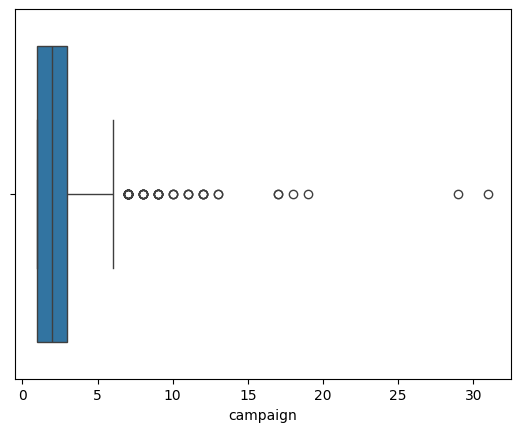

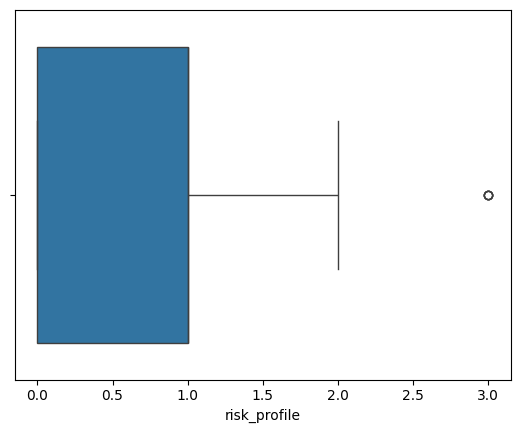

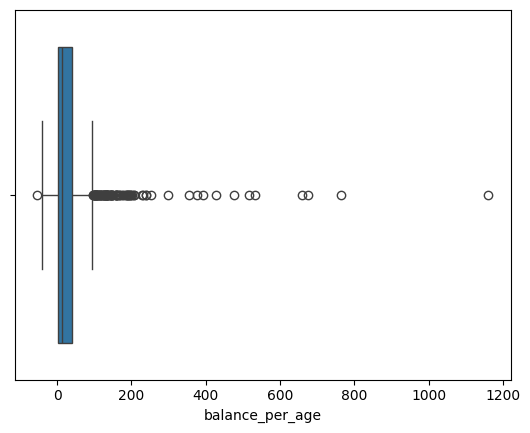

In [139]:
for i in dep_data.columns:
  if dep_data[i].dtypes in ['int64','float64'] and i not in ['wealthy_no_debt','previous_campaign_success']:
    sns.boxplot(data=dep_data, x=dep_data[i])
    plt.show()

In [140]:
q1 = dep_data.quantile(0.25, numeric_only=True)
q3 = dep_data.quantile(0.75, numeric_only=True)
iqr = q3-q1

upper = q3+ 1.5*iqr
lower = q1- 1.5*iqr

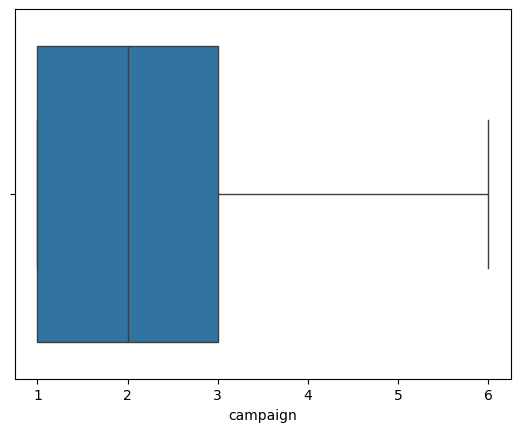

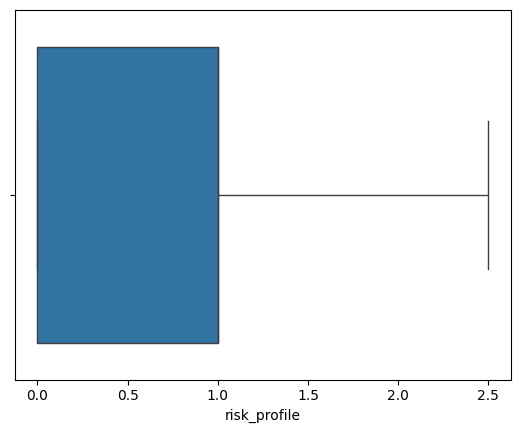

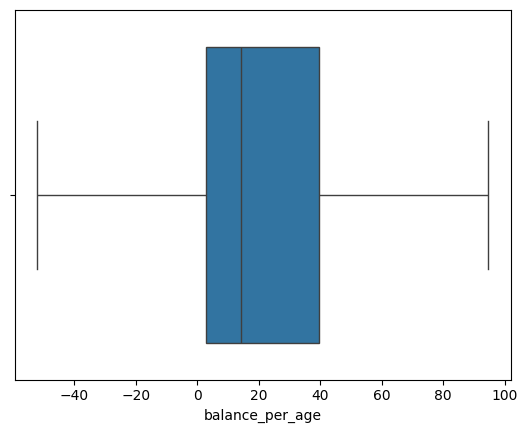

In [141]:
for i in dep_data.columns:
  if dep_data[i].dtypes in ['int64','float64'] and i not in ['wealthy_no_debt','previous_campaign_success']:
    dep_data[i] = np.where(dep_data[i]> upper[i], upper[i], dep_data[i])
    dep_data[i] = np.where(dep_data[i]< lower[i], lower[i], dep_data[i])
    sns.boxplot(data=dep_data, x=dep_data[i])
    plt.show()


In [142]:
dep_data['education'] = dep_data['education'].map({'unknown':0,'primary':1,'secondary':2,'tertiary':3})
dep_data['default'] = dep_data['default'].map({'yes':0,'no':1})
dep_data['housing'] = dep_data['housing'].map({'yes':0,'no':1})
dep_data['loan'] = dep_data['loan'].map({'yes':0,'no':1})
dep_data['response'] = dep_data['response'].map({'unknown':0,'failure':1,'success':2,'other':3})

In [143]:
dep_data= pd.get_dummies(dep_data, drop_first=True, dtype=int)

In [144]:
scaler = joblib.load('scaler.pkl')
data_scaled = scaler.transform(dep_data)
dep_data = pd.DataFrame(data_scaled, columns=dep_data.columns)

dep_data

,education,default,housing,loan,campaign,response,wealthy_no_debt,risk_profile,previous_campaign_success,balance_per_age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,-0.108176,0.128168,-0.973922,0.404540,-0.847735,-0.468231,-0.403239,0.518010,-0.265085,0.149420,2.001458,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,-1.179912,1.515181,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,1.606539,-0.304796,-0.164228,-0.147489
1,-1.372690,0.128168,1.026776,0.404540,-0.847735,-0.468231,-0.403239,-1.045495,-0.265085,-0.728036,2.001458,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,-1.179912,1.515181,-0.270087,1.724369,-0.404670,-0.088937,3.806227,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
2,-0.108176,0.128168,-0.973922,0.404540,-0.847735,-0.468231,-0.403239,0.518010,-0.265085,-0.290938,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,-1.179912,-0.659987,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,2.461664,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
3,-0.108176,0.128168,-0.973922,0.404540,-0.847735,-0.468231,-0.403239,0.518010,-0.265085,-0.297412,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,3.367403,-0.169152,-0.446713,-0.182310,-0.079088,-1.179912,1.515181,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,3.280879,-0.164228,-0.147489
4,-1.372690,0.128168,-0.973922,-2.471942,-0.212008,-0.468231,-0.403239,2.081514,-0.265085,0.544769,2.001458,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,0.847521,-0.659987,-0.270087,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,1.606539,-0.304796,-0.164228,-0.147489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,-0.108176,0.128168,-0.973922,0.404540,-0.212008,2.045275,-0.403239,0.518010,3.772369,-0.516549,2.001458,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,0.847521,-0.659987,-0.270087,-0.579922,2.471148,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
853,1.156337,0.128168,1.026776,0.404540,1.059447,-0.468231,-0.403239,-1.045495,-0.265085,-0.094244,-0.499636,-0.175134,-0.163228,1.871670,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,0.847521,-0.659987,-0.270087,-0.579922,2.471148,-0.088937,-0.262727,-0.17324,-0.406229,-0.361020,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
854,-1.372690,0.128168,-0.973922,0.404540,0.423719,-0.468231,-0.403239,0.518010,-0.265085,-0.247387,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,-0.182310,-0.079088,0.847521,-0.659987,-0.270087,1.724369,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,2.769929,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489
855,1.156337,0.128168,1.026776,0.404540,-0.847735,-0.468231,-0.403239,-1.045495,-0.265085,0.405994,-0.499636,-0.175134,-0.163228,-0.534282,-0.252262,-0.191222,-0.296965,-0.169152,-0.446713,5.485158,-0.079088,-1.179912,1.515181,3.702509,-0.579922,-0.404670,-0.088937,-0.262727,-0.17324,-0.406229,2.769929,-0.136969,-0.622456,-0.304796,-0.164228,-0.147489


In [145]:
dep_data['Prediction'] = best_knn_model.predict_proba(dep_data)[:,1]

In [146]:
dep['Prediction'] = dep_data['Prediction']
dep

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,Prediction
0,812,25,blue-collar,single,secondary,no,764,yes,no,cellular,18,may,1,-1,0,unknown,0.70
1,71,40,blue-collar,single,primary,no,118,no,no,unknown,23,feb,1,-1,0,unknown,0.72
2,912,27,admin.,divorced,secondary,no,451,yes,no,cellular,16,jul,1,-1,0,unknown,0.70
3,43,30,services,single,secondary,no,495,yes,no,cellular,21,nov,1,-1,0,unknown,0.62
4,431,36,blue-collar,married,primary,no,1548,yes,yes,cellular,18,may,2,-1,0,unknown,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,49,43,blue-collar,married,secondary,no,413,yes,no,cellular,12,aug,2,182,4,success,0.32
853,409,56,management,married,tertiary,no,1282,no,no,cellular,19,aug,4,-1,0,unknown,0.78
854,105,54,admin.,married,primary,no,976,yes,no,unknown,3,jun,3,-1,0,unknown,0.86
855,810,30,unemployed,single,tertiary,no,1159,no,no,telephone,5,jun,1,-1,0,unknown,0.46
